In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
 
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [2]:
# ------------------------------------------------------------------
# Setup
# ------------------------------------------------------------------
sns.set_style("whitegrid")
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
 
RANDOM_STATE = 42

In [3]:
# ==================================================================
# 1. EXPLORATORY DATA ANALYSIS (EDA)
# ==================================================================
 
# 1.1 Load the dataset
df = pd.read_csv("diabetes (2).csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (768, 9)


In [5]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
# 1.2 Check for missing values
print("\nMissing values (NaN) per column:\n", df.isnull().sum())


Missing values (NaN) per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nCount of implausible zeros (treated as missing) per column:")
print((df[zero_as_missing_cols] == 0).sum())


Count of implausible zeros (treated as missing) per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


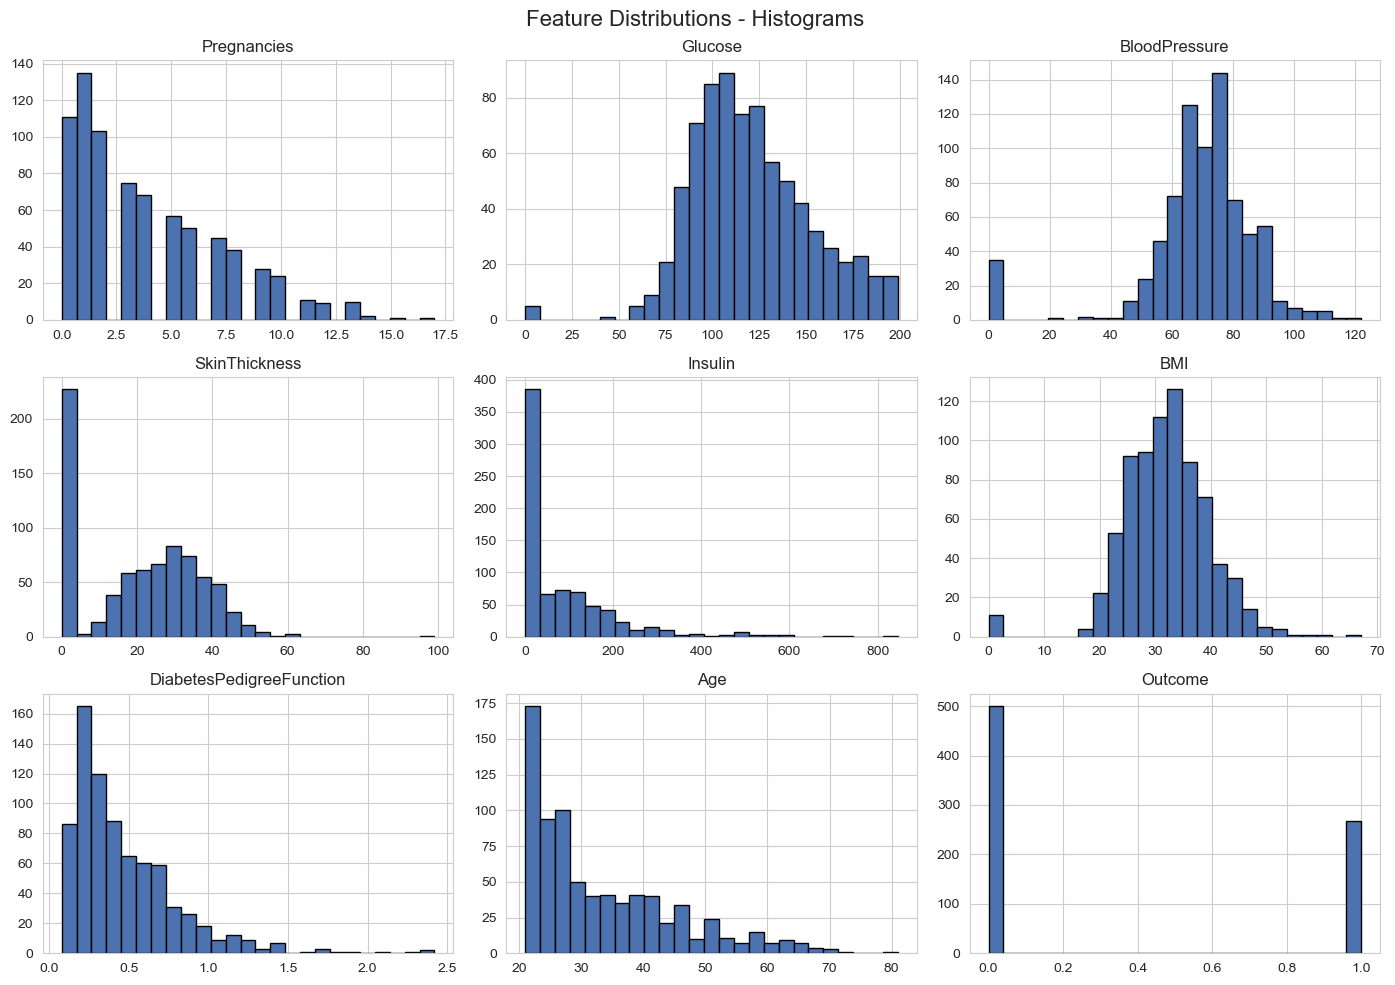

In [8]:
#================================================
# 1.3 Explore data distributions - histograms
#================================================
df.hist(figsize=(14, 10), bins=25, color="#4C72B0", edgecolor="black")
plt.suptitle("Feature Distributions - Histograms", fontsize=16)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_histograms.png", dpi=150)
plt.show()

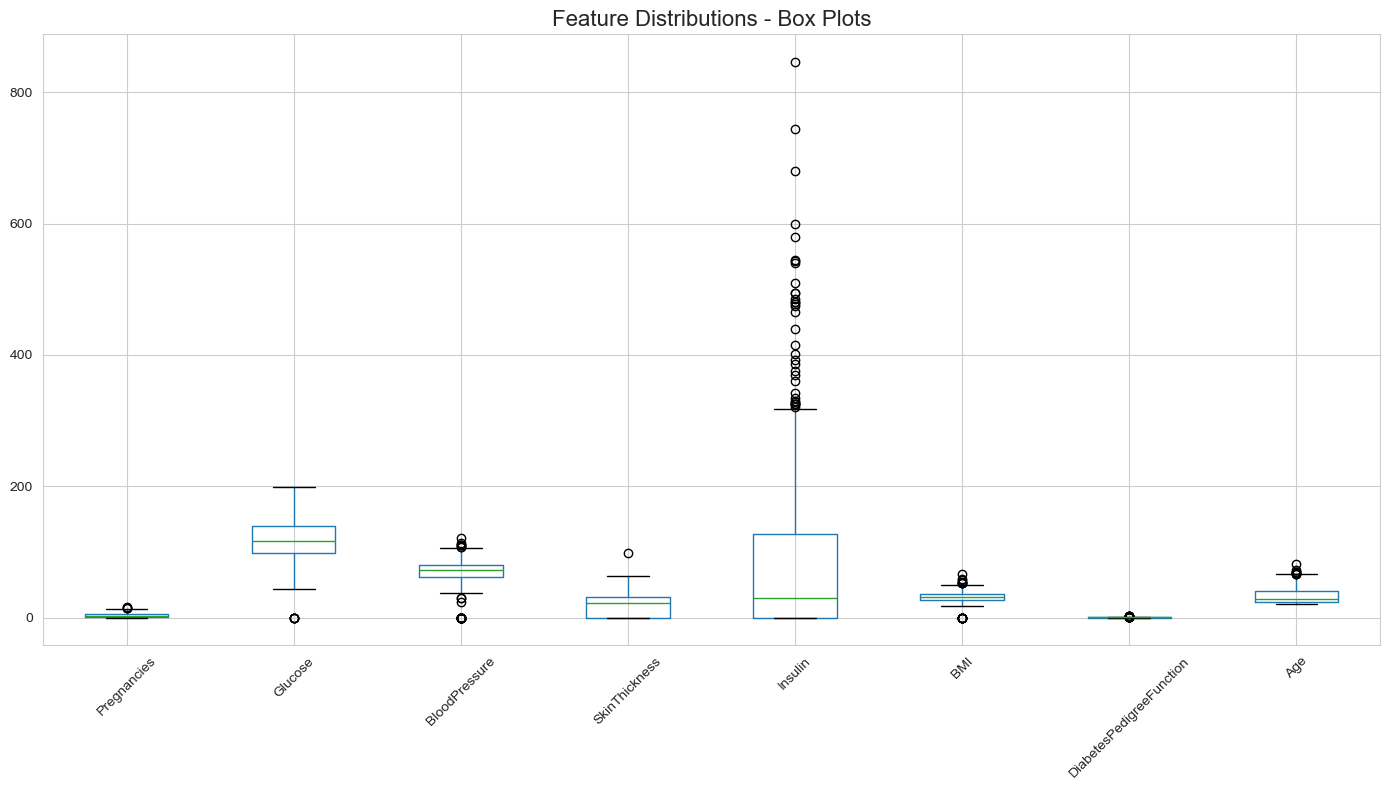

In [9]:
#====================================================
#1.3 Explore data distributions - box plots
#====================================================
plt.figure(figsize=(14, 8))
df.drop(columns=["Outcome"]).boxplot(rot=45)
plt.title("Feature Distributions - Box Plots", fontsize=16)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_boxplots.png", dpi=150)
plt.show()

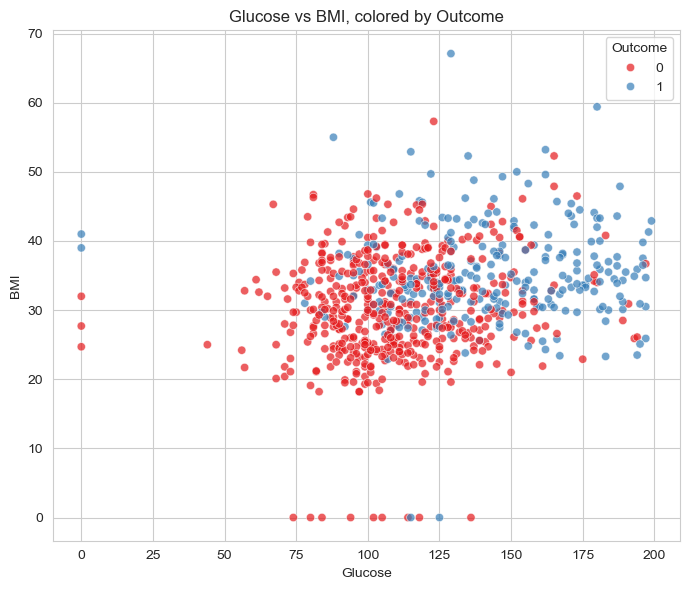

In [10]:
#===============================================================================
# 1.4 Relationships between features and target (Outcome) - scatter plots
#===============================================================================
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome", palette="Set1", alpha=0.7)
plt.title("Glucose vs BMI, colored by Outcome")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_scatter_glucose_bmi.png", dpi=150)
plt.show()

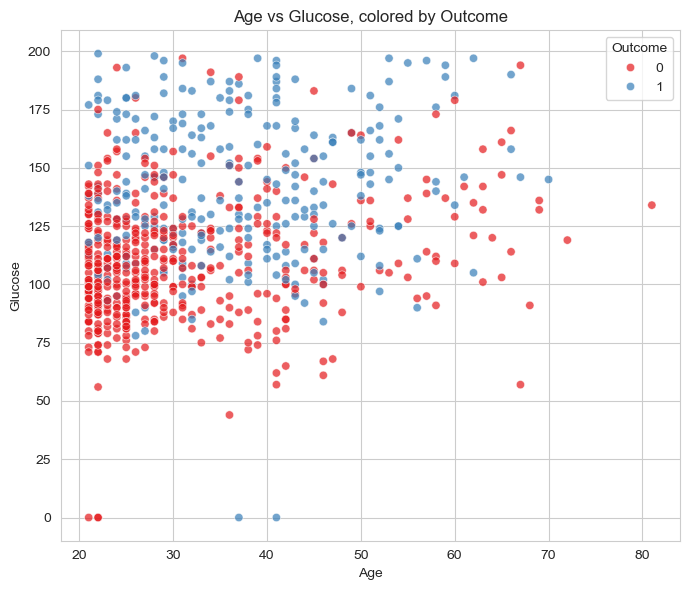

In [11]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="Age", y="Glucose", hue="Outcome", palette="Set1", alpha=0.7)
plt.title("Age vs Glucose, colored by Outcome")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_scatter_age_glucose.png", dpi=150)
plt.show()

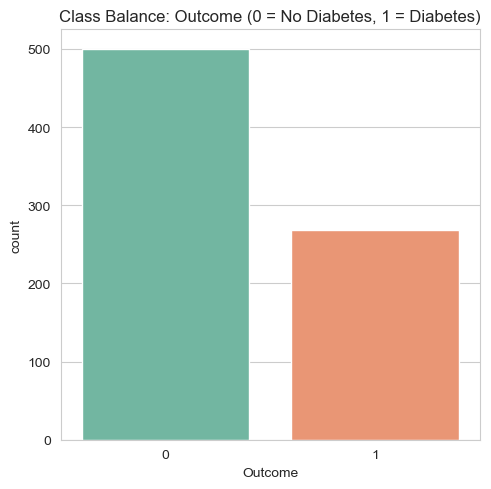

In [12]:
# 1.4 Relationships between features and target (Outcome) - bar plot
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x="Outcome", palette="Set2")
plt.title("Class Balance: Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_outcome_countplot.png", dpi=150)
plt.show()

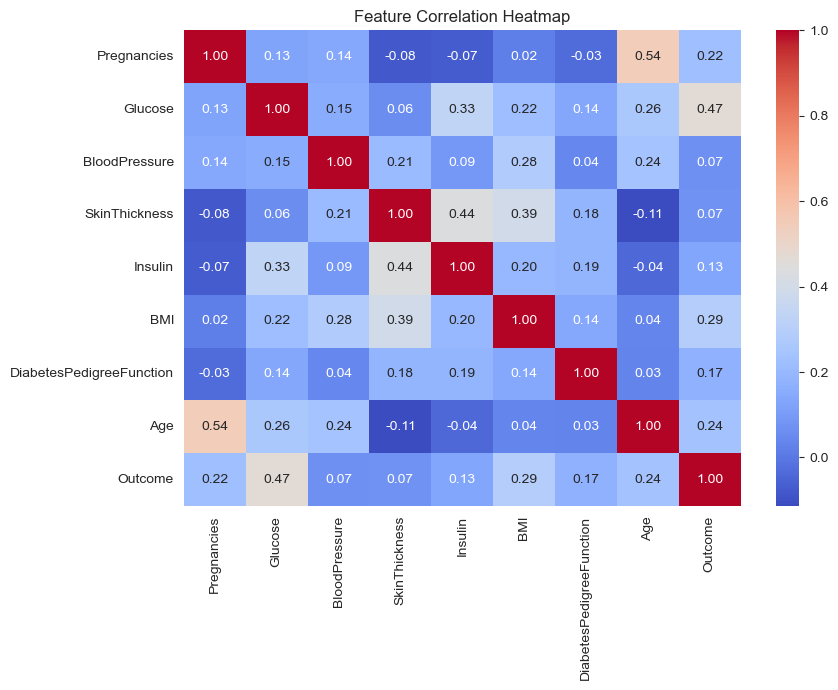


EDA plots saved to the outputs folder.


In [13]:
# Correlation heatmap (extra useful EDA view)
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_correlation_heatmap.png", dpi=150)
plt.show()
 
print("\nEDA plots saved to the outputs folder.")

In [14]:
# ==================================================================
# 2. DATA PREPROCESSING
# ==================================================================
 
# 2.1 Impute missing values
# Replace the biologically implausible zeros with NaN, then impute with
# the median of each column (median is robust to outliers/skew).
df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)
 
for col in zero_as_missing_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
 
print("\nMissing values after imputation:\n", df_clean.isnull().sum())


Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [15]:
# 2.2 Encode categorical variables
# This dataset is entirely numeric (no categorical columns), so one-hot /
# label encoding is not required. This step is included for completeness
# per the assignment instructions.
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()
if categorical_cols:
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
else:
    print("\nNo categorical columns found — one-hot encoding skipped.")
    # 2.3 Additional preprocessing: separate features/target
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]


No categorical columns found — one-hot encoding skipped.


In [16]:
# ==================================================================
# 3. BUILDING PREDICTIVE MODELS
# ==================================================================
 
# 3.1 Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (614, 8), Test shape: (154, 8)


In [17]:
# 3.2 Evaluation metrics helper
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
 
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
 
    print(f"\n--- {name} Test Set Performance ---")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

In [18]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(name, y_test, y_pred, y_proba, metrics, OUT_DIR="outputs"):
    #=======================================================
    # Confusion matrix plot
    #=======================================================
    os.makedirs(OUT_DIR, exist_ok=True)  # ensure output folder exists before saving

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=150)
    plt.show()

    return metrics, y_proba

In [19]:
 
# 3.3 & 3.4 Build and train baseline models
lgbm_base = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
lgbm_base.fit(X_train, y_train)
 
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False
)
xgb_base.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [20]:
# ==================================================================
# 4. CROSS-VALIDATION & HYPERPARAMETER TUNING
# ==================================================================
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
# 4.1 LightGBM hyperparameter search
lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 1.0],
}
 
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgbm_param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lgbm_search.fit(X_train, y_train)
lgbm_best = lgbm_search.best_estimator_
print("\nBest LightGBM params:", lgbm_search.best_params_)
print("Best LightGBM CV F1-score:", lgbm_search.best_score_)


Best LightGBM params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best LightGBM CV F1-score: 0.6395052150975198


In [24]:
# 4.2 XGBoost hyperparameter search
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
 
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
print("\nBest XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV F1-score:", xgb_search.best_score_)


Best XGBoost params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best XGBoost CV F1-score: 0.6453395826041705


In [29]:
# ==================================================================
# 5. COMPARATIVE ANALYSIS
# ==================================================================
import os
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Make sure the output directory exists
os.makedirs(OUT_DIR, exist_ok=True)


def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a fitted classifier and return:
      - metrics: dict with 'Model' plus standard classification metrics
      - proba:   predicted probabilities for the positive class
    """
    y_pred = model.predict(X_test)

    # Get probability of the positive class (assumes binary classification)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_proba


# --- Run evaluation for both models ---
lgbm_metrics, lgbm_proba = evaluate_model("LightGBM (Tuned)", lgbm_best, X_test, y_test)
xgb_metrics, xgb_proba = evaluate_model("XGBoost (Tuned)", xgb_best, X_test, y_test)

results_df = pd.DataFrame([lgbm_metrics, xgb_metrics]).set_index("Model")
print("\n=== Comparative Results Table ===")
print(results_df)
results_df.to_csv(f"{OUT_DIR}/comparison_results.csv")


=== Comparative Results Table ===
                  Accuracy  Precision    Recall        F1   ROC_AUC
Model                                                              
LightGBM (Tuned)  0.746753   0.647059  0.611111  0.628571  0.816481
XGBoost (Tuned)   0.733766   0.622642  0.611111  0.616822  0.814259


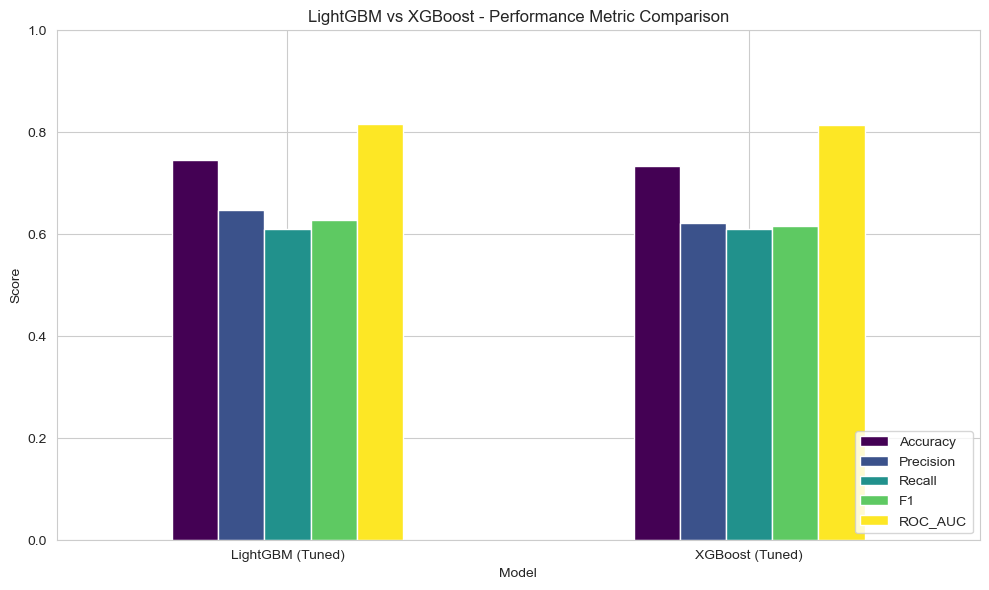

In [33]:
 
# 5.1 Bar chart comparing performance metrics
results_df.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("LightGBM vs XGBoost - Performance Metric Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/07_metric_comparison_bar.png", dpi=150)
plt.show()

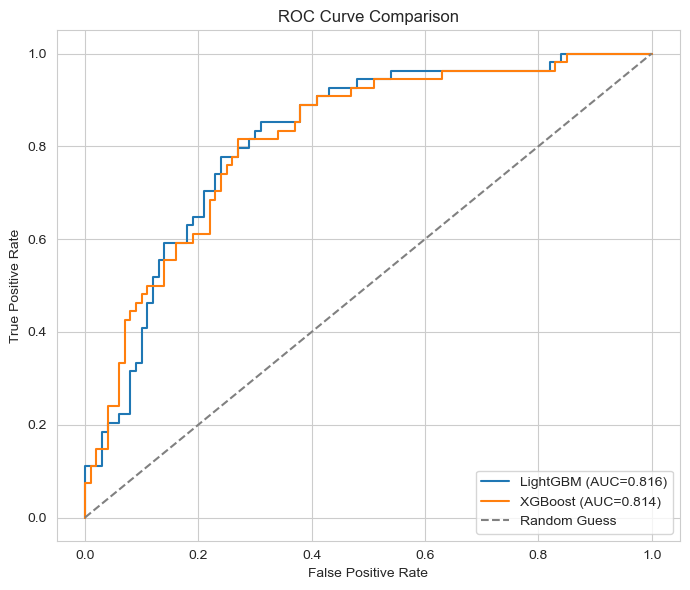

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import os

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Get predicted probabilities for the positive class (Outcome = 1)
lgbm_proba = lgbm_best.predict_proba(X_test)[:, 1]
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

# Compute ROC-AUC scores
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

# Compute ROC curve points
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC={lgbm_auc:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/08_roc_curve_comparison.png", dpi=150)
plt.show()